In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Gradient-Descent AR Model
-------------------------
Training MSE: 0.8965
Testing MSE:  0.9054
Runtime:      0.105085 seconds

Closed-Form AR Model
--------------------
Intercept: 8.5329
a1: 0.7726
a2: 0.1020
a3: 0.0400
Training MSE: 0.8965
Testing MSE:  0.9054
Runtime:      0.000194 seconds


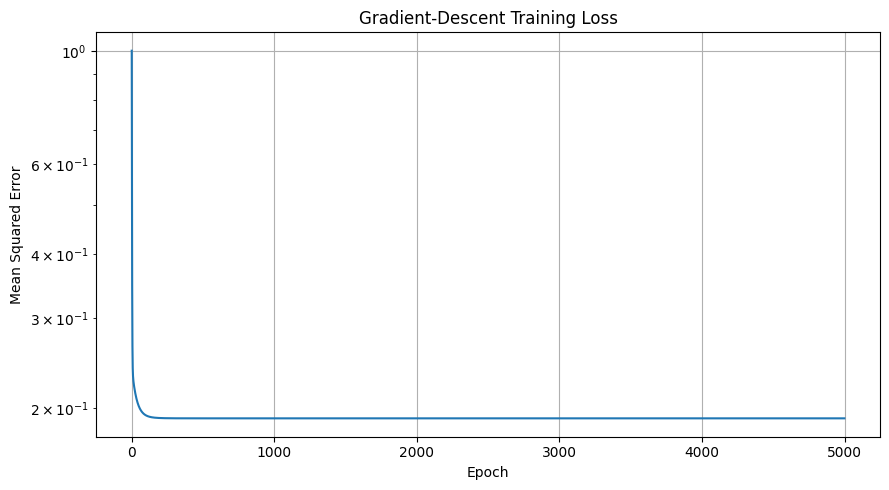

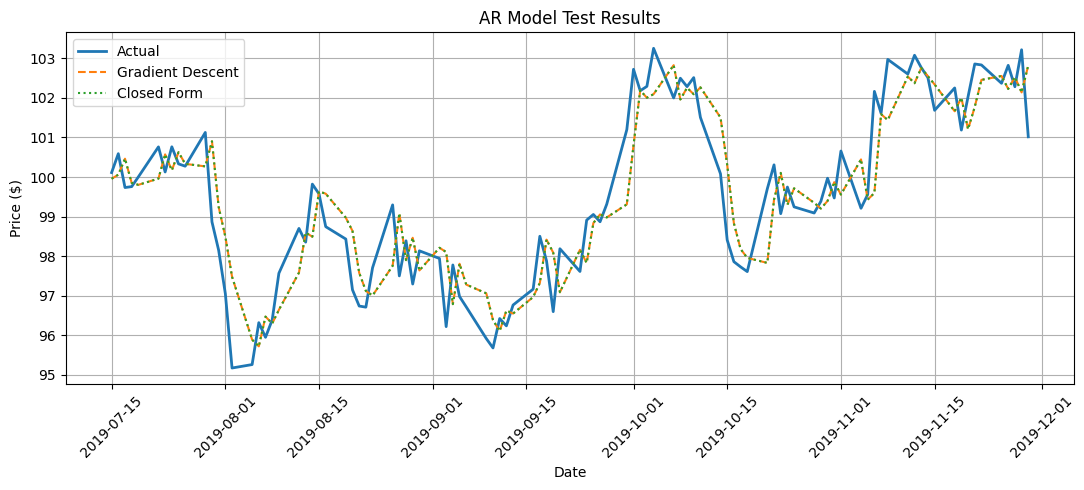

In [11]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Settings
# ============================================================

AR_ORDER = 3
EPOCHS = 5000
LEARNING_RATE = 0.05
RANDOM_SEED = 42


# ============================================================
# Generate sample data
# ============================================================

def generate_sample_data(n_days=500):
    """Generate sample stock-like prices using an AR(3) process."""
    rng = np.random.default_rng(RANDOM_SEED)

    dates = pd.bdate_range(
        start="2018-01-01",
        periods=n_days,
    )

    prices = np.zeros(n_days)
    prices[:3] = [100.0, 101.0, 100.5]

    for t in range(3, n_days):
        noise = rng.normal(0, 1)

        prices[t] = (
            5.0
            + 0.70 * prices[t - 1]
            + 0.20 * prices[t - 2]
            + 0.05 * prices[t - 3]
            + noise
        )

    return dates, prices


# ============================================================
# Prepare AR data
# ============================================================

def prepare_ar_data(values, order=3):
    """
    Create AR input samples.

    For AR(3):
        X = [y(t-1), y(t-2), y(t-3)]
        Y = y(t)
    """
    X = []
    Y = []

    for i in range(order, len(values)):
        X.append(values[i - order:i][::-1])
        Y.append(values[i])

    return np.array(X), np.array(Y)


# ============================================================
# Gradient-descent AR model
# ============================================================

def train_gradient_descent(
    X,
    Y,
    learning_rate=0.05,
    epochs=5000,
):
    """
    Train an AR model using standardized data and gradient descent.
    """
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)

    y_mean = Y.mean()
    y_std = Y.std()

    X_scaled = (X - x_mean) / x_std
    Y_scaled = (Y - y_mean) / y_std

    # Add a column for the intercept
    X_scaled = np.column_stack(
        [np.ones(len(X_scaled)), X_scaled]
    )

    weights = np.zeros(X_scaled.shape[1])
    losses = []

    for epoch in range(epochs):
        predictions = X_scaled @ weights
        errors = predictions - Y_scaled

        loss = np.mean(errors**2)
        losses.append(loss)

        gradient = (
            2 / len(Y_scaled)
        ) * X_scaled.T @ errors

        weights -= learning_rate * gradient

    model = {
        "weights": weights,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
    }

    return model, np.array(losses)


def predict_gradient_descent(model, X):
    """Make predictions using the gradient-descent model."""
    X_scaled = (
        X - model["x_mean"]
    ) / model["x_std"]

    X_scaled = np.column_stack(
        [np.ones(len(X_scaled)), X_scaled]
    )

    predictions_scaled = X_scaled @ model["weights"]

    return (
        predictions_scaled * model["y_std"]
        + model["y_mean"]
    )


# ============================================================
# Closed-form AR model
# ============================================================

def train_closed_form(X, Y):
    """
    Train an AR model using the least-squares closed-form solution.
    """
    X_with_intercept = np.column_stack(
        [np.ones(len(X)), X]
    )

    coefficients = np.linalg.lstsq(
        X_with_intercept,
        Y,
        rcond=None,
    )[0]

    return coefficients


def predict_closed_form(coefficients, X):
    """Make predictions using the closed-form model."""
    X_with_intercept = np.column_stack(
        [np.ones(len(X)), X]
    )

    return X_with_intercept @ coefficients


# ============================================================
# Main program
# ============================================================

def main():
    # Generate sample prices
    dates, prices = generate_sample_data()

    # Use 80% for training and 20% for testing
    split_index = int(len(prices) * 0.8)

    train_prices = prices[:split_index]
    test_prices = prices[split_index:]

    test_dates = dates[split_index:]

    X_train, Y_train = prepare_ar_data(
        train_prices,
        AR_ORDER,
    )

    # Include the last training observations as test lags
    combined_test_data = np.concatenate(
        [
            train_prices[-AR_ORDER:],
            test_prices,
        ]
    )

    X_test, Y_test = prepare_ar_data(
        combined_test_data,
        AR_ORDER,
    )

    # --------------------------------------------------------
    # Gradient descent
    # --------------------------------------------------------
    start_time = time.perf_counter()

    gd_model, losses = train_gradient_descent(
        X_train,
        Y_train,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
    )

    gd_runtime = time.perf_counter() - start_time

    gd_train_predictions = predict_gradient_descent(
        gd_model,
        X_train,
    )

    gd_test_predictions = predict_gradient_descent(
        gd_model,
        X_test,
    )

    gd_train_mse = np.mean(
        (Y_train - gd_train_predictions) ** 2
    )

    gd_test_mse = np.mean(
        (Y_test - gd_test_predictions) ** 2
    )

    # --------------------------------------------------------
    # Closed-form solution
    # --------------------------------------------------------
    start_time = time.perf_counter()

    closed_coefficients = train_closed_form(
        X_train,
        Y_train,
    )

    closed_runtime = time.perf_counter() - start_time

    closed_train_predictions = predict_closed_form(
        closed_coefficients,
        X_train,
    )

    closed_test_predictions = predict_closed_form(
        closed_coefficients,
        X_test,
    )

    closed_train_mse = np.mean(
        (Y_train - closed_train_predictions) ** 2
    )

    closed_test_mse = np.mean(
        (Y_test - closed_test_predictions) ** 2
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------
    print("Gradient-Descent AR Model")
    print("-------------------------")
    print(f"Training MSE: {gd_train_mse:.4f}")
    print(f"Testing MSE:  {gd_test_mse:.4f}")
    print(f"Runtime:      {gd_runtime:.6f} seconds")

    print("\nClosed-Form AR Model")
    print("--------------------")
    print(f"Intercept: {closed_coefficients[0]:.4f}")

    for i, value in enumerate(
        closed_coefficients[1:],
        start=1,
    ):
        print(f"a{i}: {value:.4f}")

    print(f"Training MSE: {closed_train_mse:.4f}")
    print(f"Testing MSE:  {closed_test_mse:.4f}")
    print(f"Runtime:      {closed_runtime:.6f} seconds")

    # --------------------------------------------------------
    # Plot training loss
    # --------------------------------------------------------
    plt.figure(figsize=(9, 5))
    plt.plot(losses)
    plt.title("Gradient-Descent Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plot test predictions
    # --------------------------------------------------------
    plt.figure(figsize=(11, 5))

    plt.plot(
        test_dates,
        Y_test,
        label="Actual",
        linewidth=2,
    )

    plt.plot(
        test_dates,
        gd_test_predictions,
        label="Gradient Descent",
        linestyle="--",
    )

    plt.plot(
        test_dates,
        closed_test_predictions,
        label="Closed Form",
        linestyle=":",
    )

    plt.title("AR Model Test Results")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()